# Decoder analysis — energy and rE-vector verification

The perceptual quality of an ambisonic decoder is summarized by, per source
direction: the decoded **energy** $E = \sum_i g_i^2$ (should be uniform), the
**energy vector** $\vec r_E = \sum_i g_i^2 \hat u_i / E$ (its direction is
where the sound appears to come from; its magnitude, ideally near 1, is image
sharpness), and the **angular error** between $\vec r_E$ and the true source
direction. This notebook computes all three from the C++ decoder matrices for
mode-matching, ALLRAD, and EPAD across the shipped layouts — the living
version of the audit's decoder verification.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ambitap_py as at

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = at.PALETTE
info = at.builtin_hrtf_info()
print(f"AmbiTap C ABI loaded — channels(order 3) = {at.channel_count(3)}, "
      f"built-in HRTF: order {info['order']}, {info['length']} taps @ {info['sample_rate']:.0f} Hz")


AmbiTap C ABI loaded — channels(order 3) = 16, built-in HRTF: order 5, 128 taps @ 44100 Hz


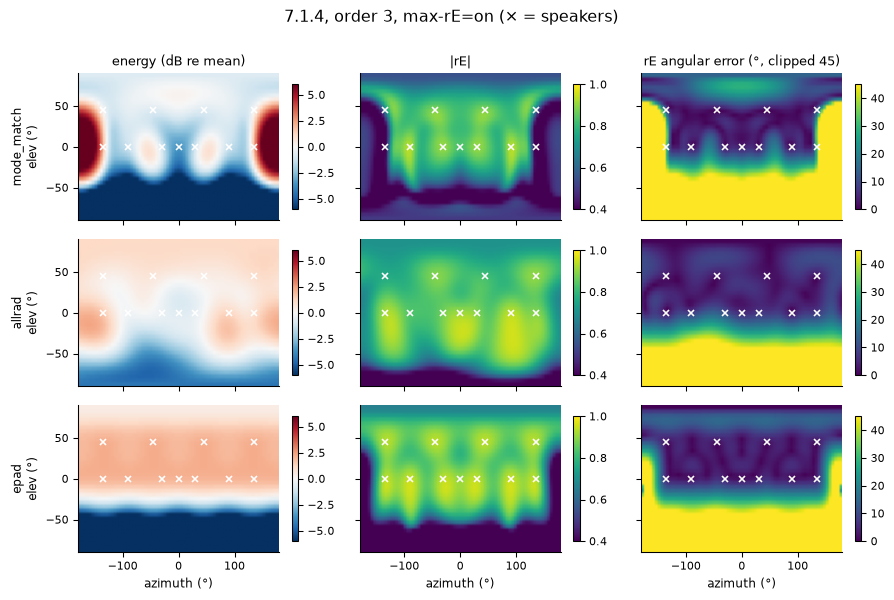

In [2]:
def unit(az, el):
    return np.array([np.cos(el) * np.cos(az), np.cos(el) * np.sin(az), np.sin(el)])

def decoder_maps(alg, layout_name, order, use_max_re, n_az=73, n_el=37):
    az_s, el_s = at.layout(layout_name)
    D = at.decoder_matrix(alg, order, az_s, el_s, use_max_re=use_max_re)
    U = np.stack([unit(a, e) for a, e in zip(az_s, el_s)])            # L x 3
    az, el, AZ, EL = at.direction_grid(n_az, n_el)
    Y = at.sh_matrix(order, AZ.ravel(), EL.ravel())                    # N x C
    G = Y @ D.T                                                        # N x L
    E = (G ** 2).sum(axis=1)
    rE = (G ** 2) @ U / E[:, None]                                     # N x 3
    mag = np.linalg.norm(rE, axis=1)
    dirs = np.stack([unit(a, e) for a, e in zip(AZ.ravel(), EL.ravel())])
    cosang = np.clip((rE * dirs).sum(axis=1) / np.maximum(mag, 1e-9), -1, 1)
    err = np.degrees(np.arccos(cosang))
    shp = AZ.shape
    return dict(E=E.reshape(shp), mag=mag.reshape(shp), err=err.reshape(shp),
                AZ=AZ, EL=EL, D=D, az_s=az_s, el_s=el_s)

def show_maps(layout_name, order, use_max_re):
    algs = ["mode_match", "allrad", "epad"]
    fig, axes = plt.subplots(3, 3, figsize=(9.5, 6.2), sharex=True, sharey=True)
    for r, alg in enumerate(algs):
        m = decoder_maps(alg, layout_name, order, use_max_re)
        panels = [
            (10 * np.log10(m["E"] / m["E"].mean()), "energy (dB re mean)", "RdBu_r", (-6, 6)),
            (m["mag"], "|rE|", "viridis", (0.4, 1.0)),
            (np.minimum(m["err"], 45), "rE angular error (°, clipped 45)", "viridis", (0, 45)),
        ]
        for c, (img, title, cmap, lim) in enumerate(panels):
            ax = axes[r, c]
            im = ax.imshow(img, origin="lower", cmap=cmap, vmin=lim[0], vmax=lim[1],
                           extent=[-180, 180, -90, 90], aspect="auto")
            ax.plot(np.degrees(m["az_s"]), np.degrees(m["el_s"]), "wx", ms=4, mew=1.2)
            ax.grid(False)
            if r == 0: ax.set_title(title)
            if c == 0: ax.set_ylabel(f"{alg}\nelev (°)")
            if r == 2: ax.set_xlabel("azimuth (°)")
            fig.colorbar(im, ax=ax, shrink=0.85)
    fig.suptitle(f"{layout_name}, order {order}, max-rE={'on' if use_max_re else 'off'} "
                 "(× = speakers)", y=1.0)
    fig.tight_layout()
    return fig

_ = show_maps("7.1.4", 3, True)


Mode-matching (top row) is exact where the layout has coverage but degrades
sharply below the horizon — the classic irregular-layout failure. ALLRAD
(middle) trades a little sharpness for robustness everywhere; EPAD sits in
between. This is why ALLRAD is the default for irregular layouts.


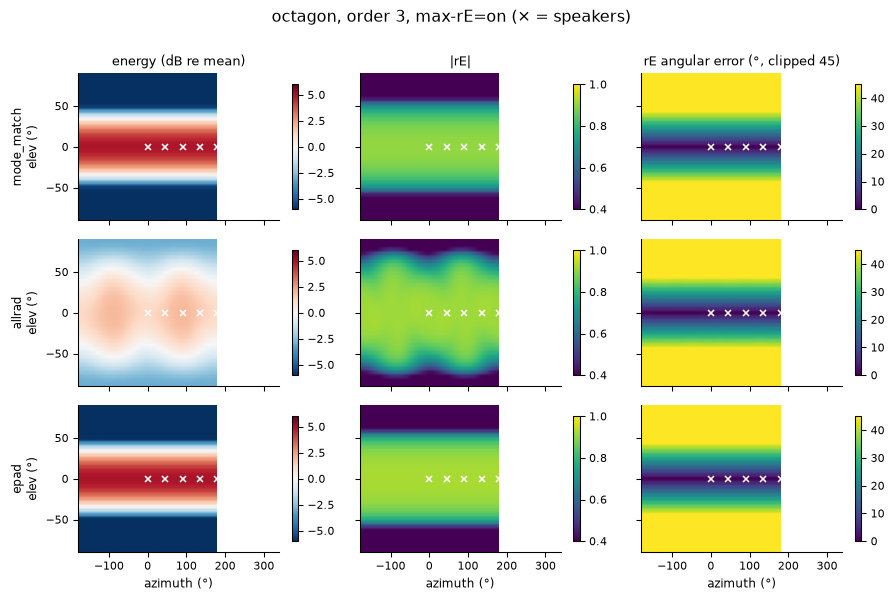

In [3]:
# The same picture on a regular horizontal ring: everything is near-perfect
# in the plane the layout can actually reproduce.
_ = show_maps("octagon", 3, True)


In [4]:
# VERIFY: quantitative gates on the maps above (in-coverage directions only).
def stats(alg, name, order, use_max_re, el_deg_limit):
    m = decoder_maps(alg, name, order, use_max_re)
    mask = np.abs(np.degrees(m["EL"])) <= el_deg_limit
    return (np.median(m["err"][mask]), np.percentile(m["err"][mask], 90),
            m["mag"][mask].mean())

med, p90, _ = stats("allrad", "7.1.4", 3, True, 28)
print(f"ALLRAD 7.1.4 (|el| ≤ 28°): median rE error {med:.1f}°, p90 {p90:.1f}°")
assert med < 15 and p90 < 30

med, _, mag_on = stats("allrad", "octagon", 3, True, 3)   # horizon row only
_, _, mag_off = stats("allrad", "octagon", 3, False, 3)
print(f"ALLRAD octagon in-plane: median error {med:.2f}°, "
      f"mean |rE| {mag_off:.3f} → {mag_on:.3f} with max-rE")
assert med < 2.0
assert mag_on > mag_off      # max-rE's whole purpose: sharper energy vector


ALLRAD 7.1.4 (|el| ≤ 28°): median rE error 8.6°, p90 25.4°
ALLRAD octagon in-plane: median error 0.09°, mean |rE| 0.880 → 0.914 with max-rE


## Absolute gain, rank handling, and a NumPy cross-check

Three regression gates from the audit, kept alive here: all decoders share
one absolute-gain convention; EPAD drops SH channels a layout cannot
reproduce (a horizontal ring has no height information); and the
mode-matching matrix equals an independently constructed N3D pseudoinverse.


omni energy, mode_match: 0.1250
omni energy, epad      : 0.1250
omni energy, allrad    : 0.3229
mode-matching vs NumPy N3D pinv (5.1, order 2): max |Δ| = 1.07e-06


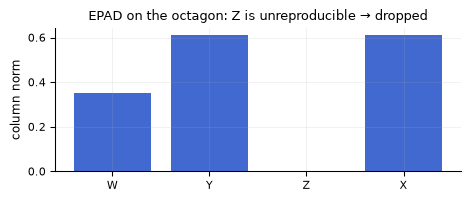

In [5]:
az_c, el_c = at.layout("cube")

# 1. Omni field -> decoded energy 1/L, identically for mode-matching and EPAD
#    on a uniform layout; ALLRAD within its coherent-VBAP-spread band.
for alg, lo, hi in [("mode_match", 0.124, 0.126), ("epad", 0.124, 0.126),
                    ("allrad", 0.11, 0.5)]:
    D = at.decoder_matrix(alg, 1, az_c, el_c)
    E = float((D[:, 0] ** 2).sum())
    print(f"omni energy, {alg:10s}: {E:.4f}")
    assert lo < E < hi

# 2. EPAD singular-value truncation: the octagon's Z column must vanish.
az_o, el_o = at.layout("octagon")
Dep = at.decoder_matrix("epad", 1, az_o, el_o)
norms = np.linalg.norm(Dep, axis=0)
fig, ax = plt.subplots(figsize=(5, 2.2))
ax.bar(["W", "Y", "Z", "X"], norms, color=[PAL[0], PAL[0], PAL[2], PAL[0]])
ax.set_ylabel("column norm"); ax.set_title("EPAD on the octagon: Z is unreproducible → dropped")
fig.tight_layout()
assert norms[2] < 1e-4

# 3. Mode-matching == NumPy N3D pseudoinverse, built from scratch.
order = 2
az_s, el_s = at.layout("5.1")
Y = at.sh_matrix(order, az_s, el_s)
f = np.sqrt(2 * np.array([int(np.sqrt(j)) for j in range(Y.shape[1])]) + 1)
D_ref = (np.linalg.pinv(Y * f).T * f).astype(np.float32)
D_cpp = at.decoder_matrix("mode_match", order, az_s, el_s)
print(f"mode-matching vs NumPy N3D pinv (5.1, order 2): "
      f"max |Δ| = {np.abs(D_cpp - D_ref).max():.2e}")
assert np.abs(D_cpp - D_ref).max() < 2e-3


energy-normalized max-rE weights preserve Σ(2n+1)·a_n² ✓


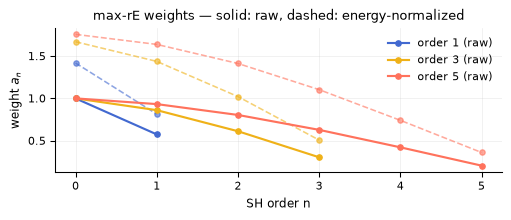

In [6]:
# max-rE weights themselves: raw weights attenuate; the energy-normalized
# variant (what the decoders apply) preserves total decoded energy.
fig, ax = plt.subplots(figsize=(5.5, 2.4))
for order, color in [(1, PAL[0]), (3, PAL[1]), (5, PAL[2])]:
    ax.plot(range(order + 1), at.max_re_weights(order), "o-", color=color,
            lw=1.6, ms=4, label=f"order {order} (raw)")
    ax.plot(range(order + 1), at.max_re_weights(order, energy_normalized=True),
            "o--", color=color, lw=1.2, ms=4, alpha=0.6)
ax.set_xlabel("SH order n"); ax.set_ylabel("weight $a_n$")
ax.set_title("max-rE weights — solid: raw, dashed: energy-normalized")
ax.legend(frameon=False)
fig.tight_layout()

for order in (1, 3, 5):
    w = at.max_re_weights(order, energy_normalized=True)
    g = 2 * np.arange(order + 1) + 1
    assert abs((g * w ** 2).sum() - g.sum()) < 1e-2 * g.sum()   # energy preserved
print("energy-normalized max-rE weights preserve Σ(2n+1)·a_n² ✓")
